# Семинар 9: логрег и SVM

## Вступление
Сегодня мы познакомимся с логистической регрессией, узнаем её особенности во время обучения и сравним с SVM. Обобщим задачу оптимизации внутри SVM с целью замены ядровой функции. Так же поговорим про метрики классификации и обсудим как их выбирать.

### План:
1. Логистическая регрессия
2. SVM
3. Ирисы Фишера. Свойства логистической регрессии и SVM
4. Логистическая регрессия и SVM на менее приятных данных
5. Метрики классификации
6. ROC-кривая
7. Бонус: вывод логистической регрессии через правдоподобие

## Логистическая регрессия

Напомним, что мы по-прежнему решаем задачу бинарной классификации, в которой целевая переменная $y$ принимает два значения: -1 и 1. На прошлом семинаре мы обсудили, что эту задачу можно решить при помощи линейного классификатора

$$
f(x_i, w) = \mathrm{sign}\left(\langle x_i, w \rangle\right).
$$

Функция потерь для такой задачи – это сумма индикаторов того, что предсказание сделано неверно:

$$Q(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}[y_i \ne \mathrm{sign}\left(\langle x_i, w \rangle\right)].$$

На лекциях мы обсуждали, что эту идею можно удобно записать через функцию отступа:

$$
Q(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}[y_i \langle x_i, w \rangle < 0].
$$

Такую функцию проблематично дифференцировать по $w$, потому что даже в местах, где градиент существует, он равен нулю. Вместо этого будем минимизировать некоторую функцию $\tilde{Q}(X, w)$, являющуюся верхней оценкой для $Q(X, w)$, и надеяться, что минимизация $\tilde{Q}(X, w)$ позволит достаточно хорошо минимизировать и $Q(X, w)$.

Логистическая регрессия предлагает использовать логистическую функцию потерь:

$$
\tilde{Q}(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}\log(1 + e^{-y_i \langle x_i, w \rangle}) \rightarrow \min_w.
$$

In [34]:
# !pip install mlxtend --upgrade

In [35]:
import itertools

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

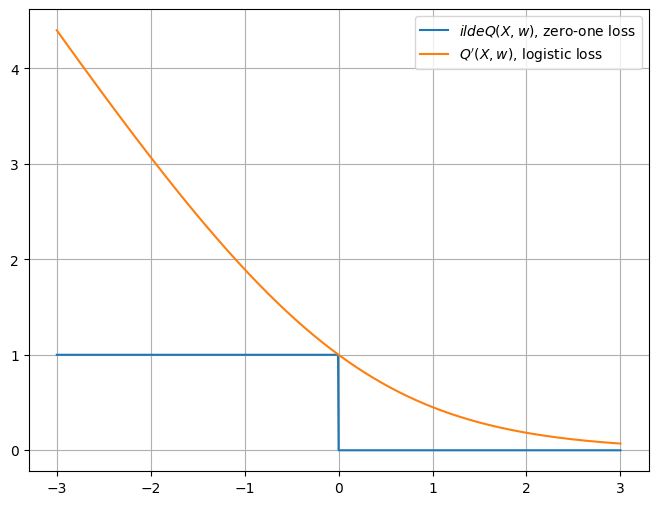

In [36]:
x = np.concatenate((np.linspace(-3, 0, 500), np.linspace(0, 3, 500)))
np.random.seed(123)
y = np.ones(1000)
w = np.ones(1000)
M = y * x * w

plt.figure(figsize=(8, 6))
plt.plot(x * w, x < 0, label="$\tilde{Q}(X, w)$, zero-one loss")
plt.plot(M, np.log2(1 + np.exp(-M)), label="$Q'(X, w)$, logistic loss")
plt.grid()
plt.legend();

Для получения классической задачи логистической регрессии остаётся сделать один шаг и немного изменить постановку задачи. Предположим, что мы хотим решать задачу **мягкой** классификации, то есть предсказывать не метку класса, а вероятность того, что наблюдение принадлежит к классу. Понятно, что мы всегда можем перейти от мягкой классификации к жёсткой, выбрав порог принадлежности к положительному классу.

**Саммари по логистической регрессии:**

- Данные: $y_i \in \{-1, 1\}$, $X$

- Предсказания:

    - По умолчанию предсказывает вероятности:
    $$
    \hat{p}_i = \sigma(\langle x_i, w\rangle) = \frac{1}{1 + e^{-\langle x_i, w\rangle}}
    $$
    
    - Если хотим перейти к метке, то сравниваем вероятность с порогом $t$:
    
    $$
    \hat{y}_i = \begin{cases}
    1,&\text{ если } \hat{p}_i > t,\\
    -1,&\text{ иначе.}
    \end{cases}
    $$
    
- Обучение:

$$
\tilde{Q}(X, w) = -\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log\sigma(\langle x_i, w \rangle) + [y_i = -1]\log(1-\sigma(\langle x_i, w \rangle) \to \min_w
$$

## Метод опорных векторов (SVM)

Метод опорных векторов — математически строго обоснованный метод, идея которого состоит в максимизации ширины разделяющей полосы между классами. Так как для подробного вывода SVM требуется уверенное владение методами квадратичной оптимизации, мы разберём только идею и практическую реализацию метода.

Мы по-прежнему решаем задачу бинарной классификации и используем классификатор $f(x_i, w) = \mathrm{sign}(\langle x_i, w\rangle)$. Предположим, что мы работаем с линейно разделимой выборкой. Определим отступ как минимальное расстояние от точек выборки до разделяющей поверхности классификатора:
$$
\rho(x_i, \langle x, w\rangle) =  \min_i\dfrac{|{\langle x_i, w\rangle|}}{\|w\|}
$$

Задача состоит в том, чтобы максимизировать этот отступ:

$$
\rho(x_i, \langle x, w\rangle) =  \min_i\dfrac{|{\langle x_i, w\rangle|}}{\|w\|} \to \max_w.
$$

Воспользуемся картинкой из Википедии, чтобы лучше понять эту идею:

[<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/1920px-SVM_margin.png" alt="drawing" width="400"/>](https://en.wikipedia.org/wiki/Support-vector_machine#/media/File:SVM_margin.png)

Заметим, что при делении весов на положительное число ответы классификатора не меняются (веса просто пропорционально прошкалируются). Поделим все веса на

$$\min_i |\langle x_i, w\rangle| > 0.$$

Тогда будет верно, что $\min_i |\langle x_i, w\rangle| = 1$, а значит отступ можно переписать как

$$
\rho(\langle x_i, w\rangle) = \frac{1}{\|w\|}.
$$

Получаем задачу SVM в линейно-разделимом случае:

$$
\begin{cases}
\|w\|^2 \to \min_{w}, \\
y_i(\langle x_i, w\rangle) \ge 1, \\
\end{cases}
$$

Если выборка не является линейно-разделимой, то нам придётся позволить линейному классификатору допускать ошибки на некоторых наблюдениях. Тогда задача превращается в поиск оптимального выбора между максимизацией ширины разделяющей полосы и ошибок классификации:

$$
\begin{cases}
\|w\|^2 + C \sum_{i = 1}^{\ell} \xi_i \to \min_{w, \xi_i}, \\
y_i(\langle x_i, w\rangle) \ge 1 - \xi_i, \\
\xi_i \ge 0
\end{cases}
$$

$C$ – параметр, который позволяет регулировать пропорции этого выбора. Чем больше $C$, тем больше штраф за неверную классификацию.

[<img src="https://miro.medium.com/max/1400/1*0vOVPBmYCkw-sUt77HtyGA.png" alt="drawing" width="800"/>](https://towardsdatascience.com/support-vector-machine-simply-explained-fee28eba5496)

Путём хитрых математических преобразований (объединив ограничения) можно показать, что итоговая функция потерь SVM выглядит следующим образом:

$$
Q(X, w) = C\sum_{i=1}^{l} \max\{0, 1 - y_i(\langle x_i, w\rangle)\} + \|w\|^2 \to \min_w
$$

### Ирисы Фишера. Свойства логистической регрессии и SVM

Рассмотрим свойства логистической регрессии и метода опорных векторов на примере классического набора данных ["Ирисы Фишера"](https://ru.wikipedia.org/wiki/Ирисы_Фишера). Этот набор состоит из 150 наблюдений, каждое из которых представляет собой четыре измерения: длина наружной доли околоцветника (`sepal length`), ширина наружной доли околоцветника (`sepal width`), длина внутренней доли околоцветника (`petal length`), ширина внутренней доли околоцветника (`petal width`). Каждое наблюдение относится к одному из трёх классов ириса: `setosa`, `versicolor` или `virginica`. Задача состоит в том, чтобы по измерениям предсказать класс цветка.

[<img src="https://miro.medium.com/v2/resize:fit:1000/1*Hh53mOF4Xy4eORjLilKOwA.png" alt="drawing" width="800"/>](https://miro.medium.com/max/1000/1*Hh53mOF4Xy4eORjLilKOwA.png)

In [37]:
data = load_iris()
X = pd.DataFrame(data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Задание 1.** Перейдём к задаче бинарной классификации: будем предсказывать принадлежность цветка к виду `versicolor` против принадлежности ко всем прочим видам. Перекодируйте зависимую переменную так, чтобы цветки вида `versicolor` имели метку 1, а прочих видов – метку -1.

In [38]:
### ваш код 

y_binary = np.where(y == 1, 1, -1)

**Задание 2**. Будем работать с двумя признаками: `sepal length (cm)` и `sepal width (cm)`. Отделите их в отдельную матрицу. Разделите выборку на обучающую и тестовую, долю тестовой выборки укажите равной 0.3. Отмасштабируйте выборки при помощи StandardScaler. Постройте диаграмму рассеяния - scatterplot - по тренировочной выборке и убедитесь, что данные линейно не разделимы.

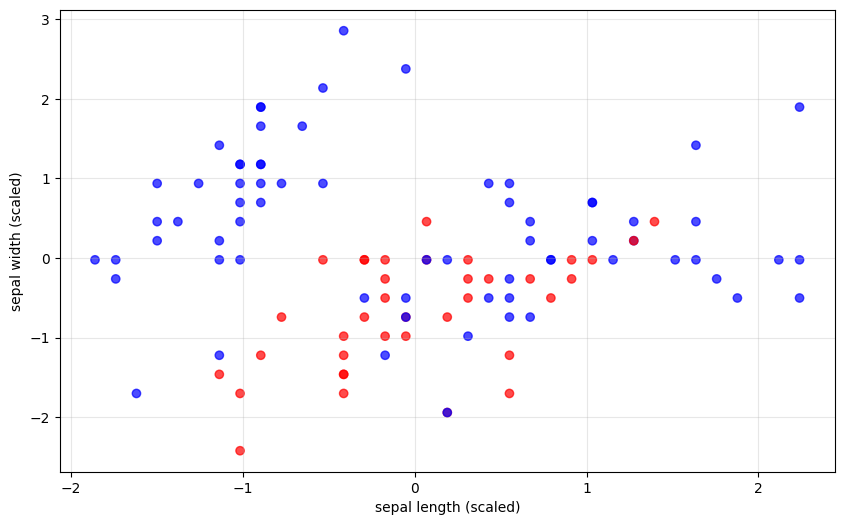

In [39]:
### ваш код здесь


X_two_features = X[['sepal length (cm)', 'sepal width (cm)']].values


X_train, X_test, y_train, y_test = train_test_split(
    X_two_features, y_binary, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


plt.figure(figsize=(10, 6))
colors = ['red' if y == 1 else 'blue' for y in y_train]
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=colors, alpha=0.7)
plt.xlabel('sepal length (scaled)')
plt.ylabel('sepal width (scaled)')
plt.grid(True, alpha=0.3)
plt.show()

**Задание 3.** Обучите логистическую регрессию и **SVM с линейным ядром** на тренировочной выборке и убедитесь, что полученные оценки весов действительно различаются. Убедитесь, что `accuracy`, возможно, не подходит в качестве метрики для данной задачи и рассчитайте `f1-меру` на тестовой выборке. Какой алгорим показал более высокое качество?

In [40]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [41]:
lr = LogisticRegression()
svm = SVC(kernel="linear")

lr.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)

print("Веса логистической регрессии:", lr.coef_[0])
print("Веса SVM", svm.coef_[0])
print()


y_pred_lr = lr.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)


print("Логистическая регрессия:")
print(classification_report(y_test, y_pred_lr, target_names=['класс -1', 'класс 1']))

print("SVM с линейным ядром:")
print(classification_report(y_test, y_pred_svm, target_names=['класс -1', 'класс 1']))


Веса логистической регрессии: [ 0.06679073 -1.38654619]
Веса SVM [-0.09072782 -1.23026595]

Логистическая регрессия:
              precision    recall  f1-score   support

    класс -1       0.74      0.88      0.80        32
     класс 1       0.43      0.23      0.30        13

    accuracy                           0.69        45
   macro avg       0.58      0.55      0.55        45
weighted avg       0.65      0.69      0.66        45

SVM с линейным ядром:
              precision    recall  f1-score   support

    класс -1       0.74      0.88      0.80        32
     класс 1       0.43      0.23      0.30        13

    accuracy                           0.69        45
   macro avg       0.58      0.55      0.55        45
weighted avg       0.65      0.69      0.66        45



Теперь посмотрим, как различаются решающие поверхности алгоритмов. Код ниже построит решающие поверхности для классификаторов. Чтобы он заработал, нужно обязательно сделать `fit` для `lr` и `svm` выше.

In [42]:

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


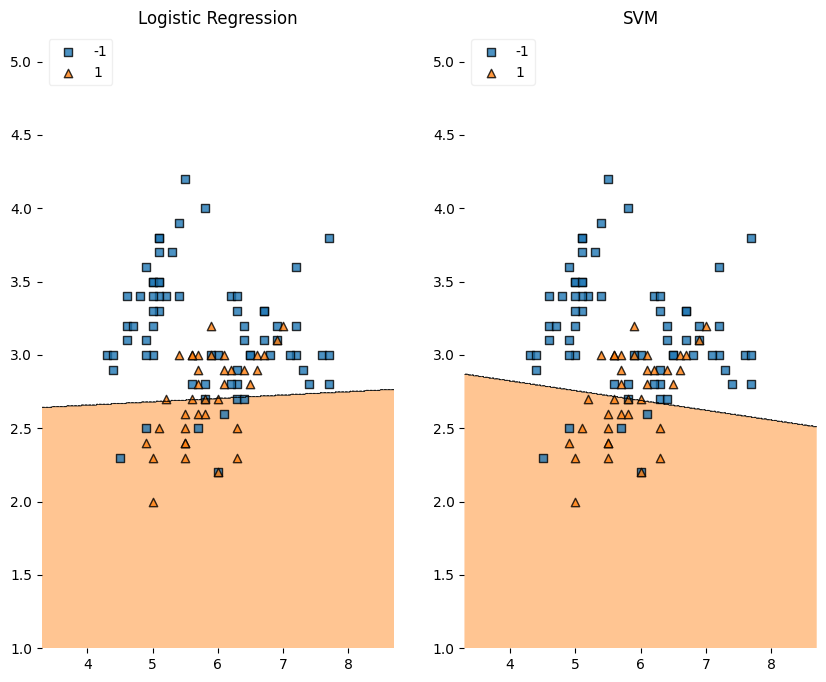

In [43]:
gs = gridspec.GridSpec(1, 2)

fig = plt.figure(figsize=(10, 8))

labels = ["Logistic Regression", "SVM"]
for clf, lab, grd in zip([lr, svm], labels, itertools.product([0, 1], repeat=2)):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(
        X=np.array(X_train), y=np.array(y_train), clf=clf, legend=2
    )
    plt.title(lab)

plt.show()

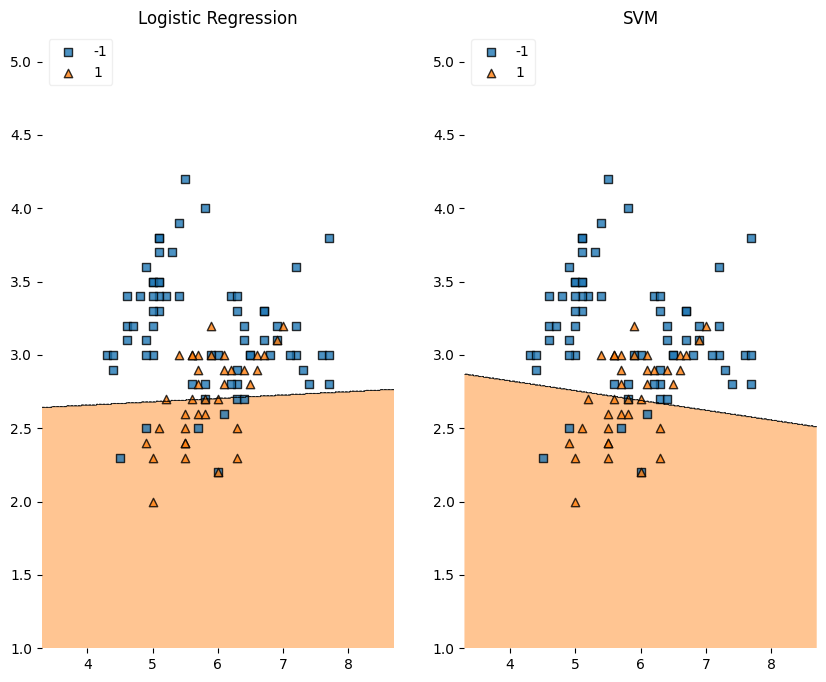

In [44]:
gs = gridspec.GridSpec(1, 2)

fig = plt.figure(figsize=(10, 8))

labels = ["Logistic Regression", "SVM"]
for clf, lab, grd in zip([lr, svm], labels, itertools.product([0, 1], repeat=2)):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(
        X=np.array(X_train), y=np.array(y_train), clf=clf, legend=2
    )
    plt.title(lab)

plt.show()

Теперь изучим свойства каждого классификатора по-отдельности. Начнём с логистической регрессии.

**Задание 3.** Обучите три различные логистические регрессии с разным параметром регуляризации $\alpha$ (обратите внимание, что в реализации `sklearn` $C = 1/\alpha$). Как изменяется разделяющая поверхность в зависимости от $\alpha$?

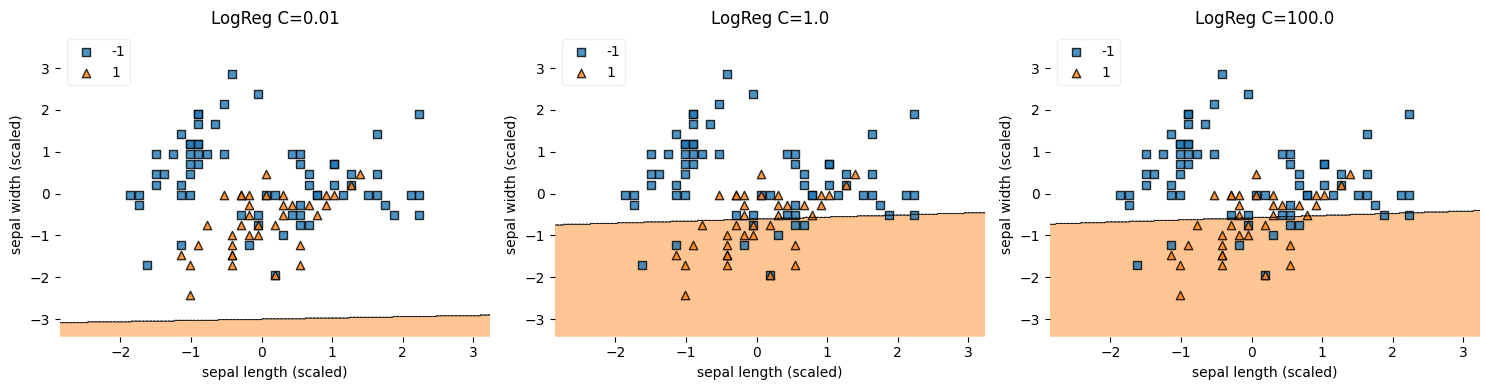

In [53]:

C_values = [0.01, 1.0, 100.0]
models_lr = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, C in enumerate(C_values):

    lr_c = LogisticRegression(C=C, random_state=42)
    lr_c.fit(X_train_scaled, y_train)
    models_lr.append(lr_c)
    

    plot_decision_regions(X_train_scaled, y_train, clf=lr_c, ax=axes[i], legend=2)
    axes[i].set_title(f'LogReg C={C}')
    axes[i].set_xlabel('sepal length (scaled)')
    axes[i].set_ylabel('sepal width (scaled)')

plt.tight_layout()
plt.show()




При  C=1.0 и при C=100.0 визуализация очень похожа 

Перейдём к SVM.

**Задание 4.** Обучите три SVM с линейным ядром с разным параметром регуляризации $C$. Как изменяется разделяющая поверхность в зависимости от $C$?

In [63]:
# Задание 4. SVM с линейным ядром и разным параметром регуляризации C
C_values_svm = [0.01, 1.0, 100.0]

print("Обучаем SVM с разными значениями C:\n")

for C in C_values_svm:
    # Обучаем SVM с разным C
    svm_c = SVC(kernel="linear", C=C, random_state=42)
    svm_c.fit(X_train, y_train)
    
    # Оцениваем качество
    y_pred = svm_c.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"C = {C}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Количество опорных векторов: {len(svm_c.support_vectors_)}")
    print()


Обучаем SVM с разными значениями C:

C = 0.01:
  Accuracy: 0.7111
  F1-score: 0.0000
  Количество опорных векторов: 76

C = 1.0:
  Accuracy: 0.7111
  F1-score: 0.3158
  Количество опорных векторов: 68

C = 100.0:
  Accuracy: 0.6889
  F1-score: 0.3000
  Количество опорных векторов: 62



Итог: Оптимальное значение C = 1.0, так как при нем достигается наилучший F1-score.



**Задание 5.** Обучите три SVM с нелинейными ядрами. Изменится ли разделяющая поверхность? Как?

In [70]:


kernels = ['poly', 'rbf', 'sigmoid']
kernel_names = ['Полиномиальное (degree=3)', 'RBF (гауссово)', 'Сигмоидальное']

for i, (kernel, name) in enumerate(zip(kernels, kernel_names)):

    if kernel == 'poly':
        svm_k = SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
    else:
        svm_k = SVC(kernel=kernel, C=1.0, random_state=42)
    
    svm_k.fit(X_train, y_train)
    

    y_pred = svm_k.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Опорных векторов: {len(svm_k.support_vectors_)}")
    print()

Полиномиальное (degree=3):
  Accuracy: 0.7333
  F1-score: 0.5000
  Опорных векторов: 61

RBF (гауссово):
  Accuracy: 0.7556
  F1-score: 0.5600
  Опорных векторов: 68

Сигмоидальное:
  Accuracy: 0.7111
  F1-score: 0.0000
  Опорных векторов: 74



RBF ядро показало лучшее качество, а сигмоидальное ядро оказалось худшим